# import Libraries

In [144]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
%matplotlib inline

#  Read Data

In [145]:
df=pd.read_csv("processed_data_all.csv")

In [146]:
df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,WhPerMile,...,modifiedAt,paymentRequired,requestedDeparture,userID,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation
0,5bc90cb9f9af8b0d7fe77cd2,2018-04-25 11:08:04,2018-04-25 13:20:10,2018-04-25 13:20:10,7.932,2_39_78_362_2018-04-25 11:08:04.400812,2,CA-496,2-39-78-362,unknown,...,unknown,unknown,unknown,unknown,12.0,26.0,Cloudy,989.11,11.0,0.0
1,5bc90cb9f9af8b0d7fe77cd3,2018-04-25 13:45:10,2018-04-26 00:56:16,2018-04-25 16:44:15,10.013,2_39_95_27_2018-04-25 13:45:09.617470,2,CA-319,2-39-95-27,unknown,...,unknown,unknown,unknown,unknown,12.0,20.0,Fog,989.44,7.0,0.0
2,5bc90cb9f9af8b0d7fe77cd4,2018-04-25 13:45:50,2018-04-25 23:04:45,2018-04-25 14:51:44,5.257,2_39_79_380_2018-04-25 13:45:49.962001,2,CA-489,2-39-79-380,unknown,...,unknown,unknown,unknown,unknown,12.0,20.0,Fog,989.44,7.0,0.0
3,5bc90cb9f9af8b0d7fe77cd5,2018-04-25 14:37:06,2018-04-25 23:55:34,2018-04-25 16:05:22,5.177,2_39_79_379_2018-04-25 14:37:06.460772,2,CA-327,2-39-79-379,unknown,...,unknown,unknown,unknown,unknown,12.0,26.0,Cloudy,990.10,6.0,0.0
4,5bc90cb9f9af8b0d7fe77cd6,2018-04-25 14:40:34,2018-04-25 23:03:12,2018-04-25 17:40:30,10.119,2_39_79_381_2018-04-25 14:40:33.638896,2,CA-490,2-39-79-381,unknown,...,unknown,unknown,unknown,unknown,12.0,26.0,Cloudy,990.10,6.0,0.0


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66423 entries, 0 to 66422
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       66423 non-null  object 
 1   connectionTime           66423 non-null  object 
 2   disconnectTime           66423 non-null  object 
 3   doneChargingTime         66423 non-null  object 
 4   kWhDelivered             66423 non-null  float64
 5   sessionID                66423 non-null  object 
 6   siteID                   66423 non-null  int64  
 7   spaceID                  66423 non-null  object 
 8   stationID                66423 non-null  object 
 9   WhPerMile                66423 non-null  object 
 10  kWhRequested             66423 non-null  object 
 11  milesRequested           66423 non-null  object 
 12  minutesAvailable         66423 non-null  object 
 13  modifiedAt               66423 non-null  object 
 14  paymentRequired       

In [148]:
print(df.index)

RangeIndex(start=0, stop=66423, step=1)


In [149]:
df['time']=df['connectionTime']
df['time']=pd.to_datetime(df['time'])
df=df.set_index('time')

# Temporal Patterns and Seasonality

## During the day

In [150]:
Three_years_hourly_counts=df.groupby(df.index.hour).size()
# total number of charges in the same time period (hour) across three years
Three_years_hourly_counts

time
0      2092
1      1819
2      1400
3      1050
4       781
5       447
6       267
7       164
8       109
9        68
10      105
11      331
12     1768
13     6354
14    10314
15    10057
16     6663
17     4476
18     3324
19     3486
20     3277
21     2807
22     2651
23     2613
dtype: int64

In [151]:
number_of_days = len(set(df.index.date))
print(number_of_days)
hourly_avg = Three_years_hourly_counts/number_of_days
hourly_avg=hourly_avg.round().astype(int)

1125


In [152]:
# Round to the nearest integer 
hourly_counts= hourly_avg.reset_index()
hourly_counts.columns = ['Hour', 'Vehicle_charging_Count']
hourly_counts

,Hour,Vehicle_charging_Count
0,0,2
1,1,2
2,2,1
3,3,1
4,4,1
5,5,0
6,6,0
7,7,0
8,8,0
9,9,0


<BarContainer object of 24 artists>

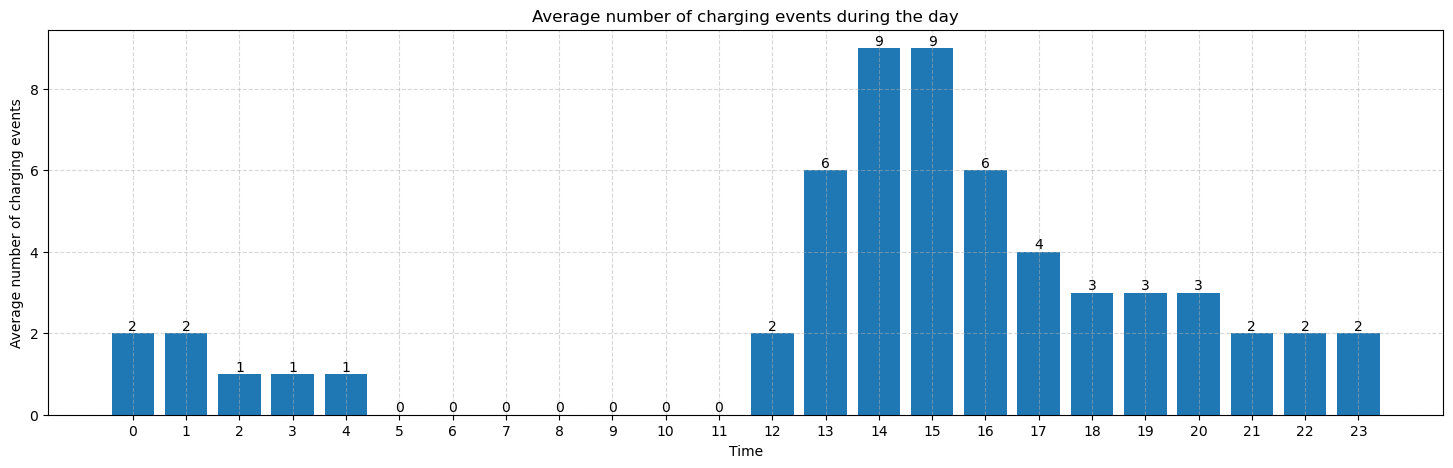

In [153]:
fig=plt.figure(figsize=(18,5))
x=hourly_counts['Hour']
y=hourly_counts['Vehicle_charging_Count']
plt.title('Average number of charging events during the day')
for (a,b) in zip(x,y):
    plt.text(x=a,y=b,s=b,ha='center',va='bottom')
plt.grid(ls="--",alpha=0.5)
plt.xticks(x)
plt.xlabel('Time')
plt.ylabel('Average number of charging events')
plt.bar(x,y)

This chart shows the average number of charging events throughout the day, revealing clear peaks and troughs. From midnight to morning (0:00 to 6:00), the number of charging events is relatively low, likely due to users sleeping during this time. Starting at noon (12:00), the demand for charging increases rapidly, peaking at 14:00 and 15:00 with 9 events, respectively. Afterward, it gradually decreases and remains stable at around 3 events in the evening. This pattern reflects users’ concentrated charging needs in the afternoon, likely after using their devices, and lower demand during the night and early morning. It is recommended to allocate charging resources efficiently during peak hours or optimize charging habits to balance demand.

## During the weeek

In [154]:
df.index.dayofweek

Index([2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       ...
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
      dtype='int32', name='time', length=66423)

In [155]:
# the number of weekdays
unique_dates = df.index.normalize().unique()
Monday_count =(pd.to_datetime(unique_dates).dayofweek == 0).sum()
print("Number of Mondays:",Monday_count)
Tuesday_count =(pd.to_datetime(unique_dates).dayofweek == 1).sum()
print("Number of Tuesdays:",Tuesday_count)
Wednesday_count =(pd.to_datetime(unique_dates).dayofweek == 2).sum()
print("Number of Wednesdays:",Wednesday_count)
Thursday_count =(pd.to_datetime(unique_dates).dayofweek == 3).sum()
print("Number of Thursdays:",Thursday_count)
Friday_count =(pd.to_datetime(unique_dates).dayofweek == 4).sum()
print("Number of Fridays:",Friday_count)
Saturday_count =(pd.to_datetime(unique_dates).dayofweek == 5).sum()
print("Number of Saturdays:",Saturday_count)
Sunday_count =(pd.to_datetime(unique_dates).dayofweek == 6).sum()
print("Number of Sundays:",Sunday_count)

Number of Mondays: 161
Number of Tuesdays: 161
Number of Wednesdays: 161
Number of Thursdays: 162
Number of Fridays: 162
Number of Saturdays: 158
Number of Sundays: 160


In [156]:
day_counts=pd.Series([Monday_count, Tuesday_count, Wednesday_count, Thursday_count, Friday_count, Saturday_count, Sunday_count],
                     index=['Mon','Tues','Wed','Thurs','Fri','Sat','Sun'])
print(day_counts)

Mon      161
Tues     161
Wed      161
Thurs    162
Fri      162
Sat      158
Sun      160
dtype: int32


In [157]:
weekday=df.groupby(df.index.dayofweek).size()
weekday.index=['Mon','Tues','Wed','Thurs','Fri','Sat','Sun']
weekday

Mon      11515
Tues     12853
Wed      12732
Thurs    12533
Fri      10762
Sat       3394
Sun       2634
dtype: int64

In [158]:
average_numbe_of_charging=weekday/day_counts
average_numbe_of_charging=average_numbe_of_charging.round().astype(int)
print(average_numbe_of_charging)

Mon      72
Tues     80
Wed      79
Thurs    77
Fri      66
Sat      21
Sun      16
dtype: int32


In [159]:
Day_counts= average_numbe_of_charging.reset_index()
Day_counts.columns = ['Weekday', 'Vehicle_charging_Counts']
Day_counts

,Weekday,Vehicle_charging_Counts
0,Mon,72
1,Tues,80
2,Wed,79
3,Thurs,77
4,Fri,66
5,Sat,21
6,Sun,16


<BarContainer object of 7 artists>

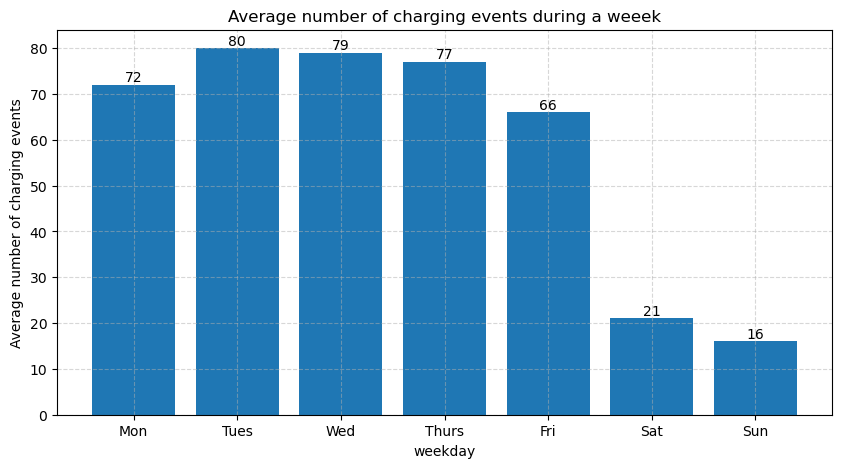

In [160]:
fig=plt.figure(figsize=(10,5))
x=Day_counts['Weekday']
y=Day_counts['Vehicle_charging_Counts']
plt.title('Average number of charging events during a weeek')
for (a,b) in zip(x,y):
    plt.text(x=a,y=b,s=b,ha='center',va='bottom')
plt.grid(ls="--",alpha=0.5)
plt.xticks(ticks=range(len(x)), labels=x)  
plt.xlabel('weekday')
plt.ylabel('Average number of charging events')
plt.bar(x,y)

This chart illustrates the average number of charging events during a week, showing a clear distinction between weekdays and weekends. Charging activity is significantly higher on weekdays, peaking on Tuesday (80) and Wednesday (79), with consistent usage from Monday to Thursday. However, there is a noticeable decline starting Friday (66), dropping sharply to 21 on Saturday and 16 on Sunday. This pattern suggests that charging behavior is closely tied to workweek travel and commuting needs, while reduced activity on weekends reflects less frequent vehicle usage or alternative travel habits.

### Charging patterns during a weekday and a weekend

In [162]:
week=np.where(df.index.weekday<5,'weekday','weekend')
charging_events_per_hour=df.groupby([week,df.index.hour]).size()
print(charging_events_per_hour)

         time
weekday  0        1661
         1        1473
         2        1108
         3         828
         4         604
         5         327
         6         171
         7         107
         8          68
         9          51
         10         93
         11        316
         12       1721
         13       6258
         14      10054
         15       9747
         16       6260
         17       3983
         18       2824
         19       3030
         20       2821
         21       2407
         22       2260
         23       2223
weekend  0         431
         1         346
         2         292
         3         222
         4         177
         5         120
         6          96
         7          57
         8          41
         9          17
         10         12
         11         15
         12         47
         13         96
         14        260
         15        310
         16        403
         17        493
         18        5

In [170]:
weekday_charging_events_per_hour=charging_events_per_hour['weekday']/(162*5)
weekday_charging_events_per_hour=weekday_charging_events_per_hour.round().astype(int)
weekend_charging_events_per_hour=charging_events_per_hour['weekend']/(160*2)
weekend_charging_events_per_hour=weekend_charging_events_per_hour.round().astype(int)
print(weekday_charging_events_per_hour)

time
0      2
1      2
2      1
3      1
4      1
5      0
6      0
7      0
8      0
9      0
10     0
11     0
12     2
13     8
14    12
15    12
16     8
17     5
18     3
19     4
20     3
21     3
22     3
23     3
dtype: int32


In [171]:
print(weekend_charging_events_per_hour)

time
0     1
1     1
2     1
3     1
4     1
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    1
15    1
16    1
17    2
18    2
19    1
20    1
21    1
22    1
23    1
dtype: int32


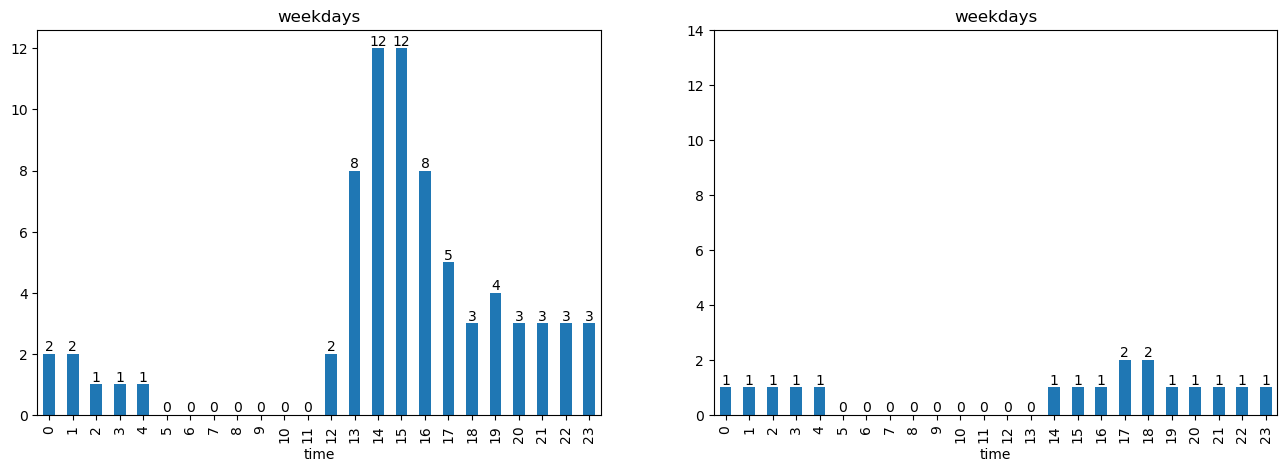

In [185]:
fig,ax=plt.subplots(1,2,figsize=(16,5))
y_min,y_max=0,14
weekday_bars=weekday_charging_events_per_hour.plot(kind='bar',ax=ax[0],title='weekdays')
for bar in weekday_bars.patches:
    ax[0].text(bar.get_x() + bar.get_width()/2, 
               bar.get_height(),             
               f'{int(bar.get_height())}', 
               ha='center', va='bottom') 
weekend_bars=weekend_charging_events_per_hour.plot(kind='bar',ax=ax[1],title='weekdays')
ax[1].set_ylim(y_min, y_max)
for bar in weekend_bars.patches:
    ax[1].text(bar.get_x() + bar.get_width()/2, 
               bar.get_height(),             
               f'{int(bar.get_height())}', 
               ha='center', va='bottom') 

## between the seasons

Text(0, 0.5, 'Daily charging events')

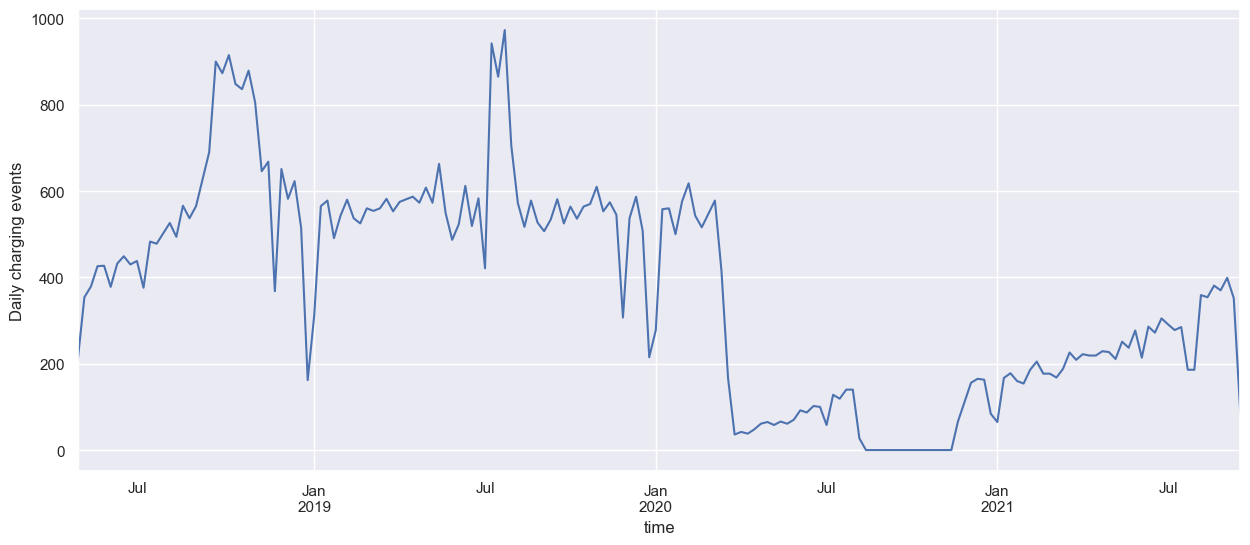

In [60]:
fig,ax=plt.subplots(figsize=(15,6))
daily_counts_week.plot()
plt.ylabel('Daily charging events')

Text(0, 0.5, 'Events')

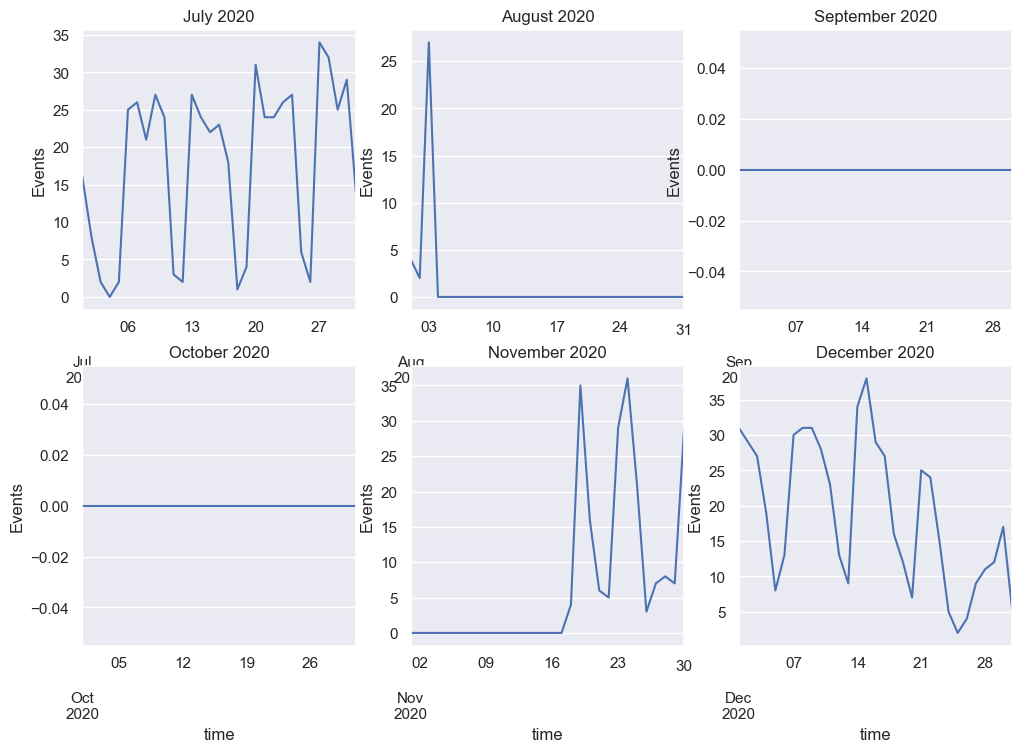

In [57]:
fig,axes = plt.subplots (2,3,figsize=(12,8))
daily_counts['2020-7'].plot(ax=axes[0, 0])
axes[0, 0].set_title('July 2020')
axes[0, 0].set_ylabel('Events')
daily_counts['2020-8'].plot(ax=axes[0, 1])
axes[0, 1].set_title('August 2020')
axes[0, 1].set_ylabel('Events')
daily_counts['2020-9'].plot(ax=axes[0, 2])
axes[0, 2].set_title('September 2020')
axes[0, 2].set_ylabel('Events')
daily_counts['2020-10'].plot(ax=axes[1,0])
axes[1,0].set_title('October 2020')
axes[1,0].set_ylabel('Events')
daily_counts['2020-11'].plot(ax=axes[1,1])
axes[1,1].set_title('November 2020')
axes[1,1].set_ylabel('Events')
daily_counts['2020-12'].plot(ax=axes[1, 2])
axes[1,2].set_title('December 2020')
axes[1,2].set_ylabel('Events')

